In [1]:
from tempfile import TemporaryDirectory


In [3]:
pip install flopy

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 27.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import flopy

In [40]:
temp_dir = TemporaryDirectory()
workspace = temp_dir.name
name = "tutorial01"

In [41]:
# set up simulation and basic packages
sim = flopy.mf6.MFSimulation(sim_name=name, sim_ws=workspace)
flopy.mf6.ModflowTdis(sim, nper=10, perioddata=[[365.0, 1, 1.0] for _ in range(10)])
flopy.mf6.ModflowIms(sim)
gwf = flopy.mf6.ModflowGwf(sim, modelname=name, save_flows=True)
botm = [30.0, 20.0, 10.0]
flopy.mf6.ModflowGwfdis(gwf, nlay=3, nrow=4, ncol=5, top=50.0, botm=botm)
flopy.mf6.ModflowGwfic(gwf)
flopy.mf6.ModflowGwfnpf(gwf, save_specific_discharge=True)
flopy.mf6.ModflowGwfchd(gwf, stress_period_data=[[(0, 0, 0), 1.0], [(2, 3, 4), 0.0]])
budget_file = f"{name}.bud"
head_file = f"{name}.hds"
flopy.mf6.ModflowGwfoc(
    gwf,
    budget_filerecord=budget_file,
    head_filerecord=head_file,
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
)
print("Done creating simulation.")

Done creating simulation.


In [43]:
sim.simulation_data.verbosity_level = 3

In [44]:
sim.simulation_data.indent_string = "    "

In [45]:
sim.float_precision = 8
sim.float_characters = 15

In [46]:
sim.verify_data = True
sim.auto_set_sizes = True

In [47]:
print(sim)

sim_name = tutorial01
sim_path = C:\Users\ROSAMA~1.MOR\AppData\Local\Temp\tmpmv6uth59
exe_name = mf6

###################
Package mfsim.nam
###################

package_name = mfsim.nam
filename = mfsim.nam
package_type = nam
model_or_simulation_package = simulation
simulation_name = tutorial01


###################
Package tutorial01.tdis
###################

package_name = tutorial01.tdis
filename = tutorial01.tdis
package_type = tdis
model_or_simulation_package = simulation
simulation_name = tutorial01


###################
Package ims_-1
###################

package_name = ims_-1
filename = tutorial01.ims
package_type = ims
model_or_simulation_package = simulation
simulation_name = tutorial01


@@@@@@@@@@@@@@@@@@@@
Model tutorial01
@@@@@@@@@@@@@@@@@@@@

name = tutorial01
model_type = gwf6
version = mf6
model_relative_path = .

###################
Package dis
###################

package_name = dis
filename = tutorial01.dis
package_type = dis
model_or_simulation_package = model
mode

In [48]:
from pathlib import Path
from tempfile import TemporaryDirectory

In [49]:
import matplotlib.pyplot as plt
import numpy as np

In [50]:
h1 = 100
Nlay = 10
N = 101
L = 400.0
H = 50.0
k = 1.0
q = -1000.0

In [51]:
temp_dir = TemporaryDirectory()
workspace = Path(temp_dir.name)
name = "tutorial01_mf6"
sim = flopy.mf6.MFSimulation(
    sim_name=name, exe_name="mf6", version="mf6", sim_ws=workspace
)

In [52]:
tdis = flopy.mf6.ModflowTdis(
    sim, pname="tdis", time_units="DAYS", nper=1, perioddata=[(1.0, 1, 1.0)]
)

In [53]:
ims = flopy.mf6.ModflowIms(
    sim,
    pname="ims",
    complexity="SIMPLE",
    linear_acceleration="BICGSTAB",
)

In [54]:
model_nam_file = f"{name}.nam"
gwf = flopy.mf6.ModflowGwf(
    sim,
    modelname=name,
    model_nam_file=model_nam_file,
    save_flows=True,
    newtonoptions="NEWTON UNDER_RELAXATION",
)

In [55]:
bot = np.linspace(-H / Nlay, -H, Nlay)
delrow = delcol = L / (N - 1)
dis = flopy.mf6.ModflowGwfdis(
    gwf,
    nlay=Nlay,
    nrow=N,
    ncol=N,
    delr=delrow,
    delc=delcol,
    top=0.0,
    botm=bot,
)

In [56]:
start = h1 * np.ones((Nlay, N, N))
ic = flopy.mf6.ModflowGwfic(gwf, pname="ic", strt=start)

In [57]:
npf = flopy.mf6.ModflowGwfnpf(gwf, icelltype=1, k=k)

In [58]:
chd_rec = []
layer = 0
for row_col in range(0, N):
    chd_rec.append(((layer, row_col, 0), h1))
    chd_rec.append(((layer, row_col, N - 1), h1))
    if row_col != 0 and row_col != N - 1:
        chd_rec.append(((layer, 0, row_col), h1))
        chd_rec.append(((layer, N - 1, row_col), h1))
chd = flopy.mf6.ModflowGwfchd(gwf, stress_period_data=chd_rec)

In [59]:
iper = 0
ra = chd.stress_period_data.get_data(key=iper)
ra

rec.array([((0, 0, 0), 100), ((0, 0, 100), 100), ((0, 1, 0), 100),
           ((0, 1, 100), 100), ((0, 0, 1), 100), ((0, 100, 1), 100),
           ((0, 2, 0), 100), ((0, 2, 100), 100), ((0, 0, 2), 100),
           ((0, 100, 2), 100), ((0, 3, 0), 100), ((0, 3, 100), 100),
           ((0, 0, 3), 100), ((0, 100, 3), 100), ((0, 4, 0), 100),
           ((0, 4, 100), 100), ((0, 0, 4), 100), ((0, 100, 4), 100),
           ((0, 5, 0), 100), ((0, 5, 100), 100), ((0, 0, 5), 100),
           ((0, 100, 5), 100), ((0, 6, 0), 100), ((0, 6, 100), 100),
           ((0, 0, 6), 100), ((0, 100, 6), 100), ((0, 7, 0), 100),
           ((0, 7, 100), 100), ((0, 0, 7), 100), ((0, 100, 7), 100),
           ((0, 8, 0), 100), ((0, 8, 100), 100), ((0, 0, 8), 100),
           ((0, 100, 8), 100), ((0, 9, 0), 100), ((0, 9, 100), 100),
           ((0, 0, 9), 100), ((0, 100, 9), 100), ((0, 10, 0), 100),
           ((0, 10, 100), 100), ((0, 0, 10), 100), ((0, 100, 10), 100),
           ((0, 11, 0), 100), ((0, 11, 100),

In [60]:
wel_rec = [(Nlay - 1, int(N / 4), int(N / 4), q)]
wel = flopy.mf6.ModflowGwfwel(gwf, stress_period_data=wel_rec)

In [62]:
headfile = f"{name}.hds"
head_filerecord = [headfile]
budgetfile = f"{name}.cbb"
budget_filerecord = [budgetfile]
saverecord = [("HEAD", "ALL"), ("BUDGET", "ALL")]
printrecord = [("HEAD", "LAST")]
oc = flopy.mf6.ModflowGwfoc(
    gwf,
    saverecord=saverecord,
    head_filerecord=head_filerecord,
    budget_filerecord=budget_filerecord,
    printrecord=printrecord,
)

In [63]:
sim.write_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims...
  writing model tutorial01_mf6...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package chd_0...
INFORMATION: maxbound in ('gwf6', 'chd', 'dimensions') changed to 400 based on size of stress_period_data
    writing package wel_0...
INFORMATION: maxbound in ('gwf6', 'wel', 'dimensions') changed to 1 based on size of stress_period_data
    writing package oc...


In [36]:
flopy.utils.get_modflow(":flopy")

auto-selecting option ':flopy' for 'bindir'
fetched release '21.0' info from MODFLOW-USGS/executables
downloading 'https://github.com/MODFLOW-ORG/executables/releases/download/21.0/win64.zip' to 'C:\Users\rosamaria.moreno\Downloads\modflow_executables-21.0-win64.zip'
extracting 25 files to 'C:\Users\rosamaria.moreno\AppData\Local\flopy\bin'
crt.exe (1.3.1)         mfnwt.exe (1.3.0)       sutra.exe (4.0)
gridgen.exe (1.0.02)    mfnwtdbl.exe (1.3.0)    swtv4.exe (4.00.05)
libmf6.dll (6.6.1)      mfusg.exe (1.5)         triangle.exe (1.6)
mf2000.exe (1.19.01)    mfusgdbl.exe (1.5)      vs2dt.exe (3.3)
mf2005.exe (1.12.00)    mfusg_gsi.exe (2.4.0)   zbud6.exe (6.6.1)
mf2005dbl.exe (1.12.00) mp6.exe (6.0.1)         zonbud3.exe (3.01)
mf6.exe (6.6.1)         mp7.exe (7.2.001)       zonbudusg.exe (1.5)
mflgr.exe (2.0.0)       mt3dms.exe (5.3.0)
mflgrdbl.exe (2.0.0)    mt3dusgs.exe (1.1.0)
wrote new flopy metadata file: 'C:\Users\rosamaria.moreno\AppData\Local\flopy\get_modflow.json'


In [37]:
flopy.which("mf6")

'C:\\Users\\rosamaria.moreno\\AppData\\Local\\flopy\\bin\\mf6.EXE'

In [65]:
success, buff = sim.run_simulation()
assert success, "MODFLOW 6 did not terminate normally."

FloPy is using the following executable to run the model: ..\..\..\..\..\rosamaria.moreno\AppData\Local\flopy\bin\mf6.exe
                                   MODFLOW 6
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                            VERSION 6.6.1 02/10/2025

   MODFLOW 6 compiled Feb 14 2025 13:40:10 with Intel(R) Fortran Intel(R) 64
   Compiler Classic for applications running on Intel(R) 64, Version 2021.7.0
                             Build 20220726_000000

This software has been approved for release by the U.S. Geological 
Survey (USGS). Although the software has been subjected to rigorous 
review, the USGS reserves the right to update the software as needed 
pursuant to further analysis and review. No warranty, expressed or 
implied, is made by the USGS or the U.S. Government as to the 
functionality of the software and related material nor shall the 
fact of release constitute any such warranty. Furthermore, the 
software is released on condition that n

In [66]:
h = gwf.output.head().get_data(kstpkper=(0, 0))
x = y = np.linspace(0, L, N)
y = y[::-1]
vmin, vmax = 90.0, 100.0
contour_intervals = np.arange(90, 100.1, 1.0)

<a list of 6 text.Text objects>

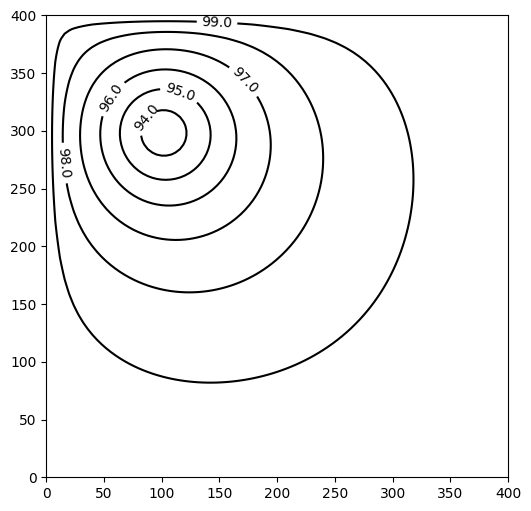

In [67]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, aspect="equal")
c = ax.contour(x, y, h[0], contour_intervals, colors="black")
plt.clabel(c, fmt="%2.1f")

<a list of 11 text.Text objects>

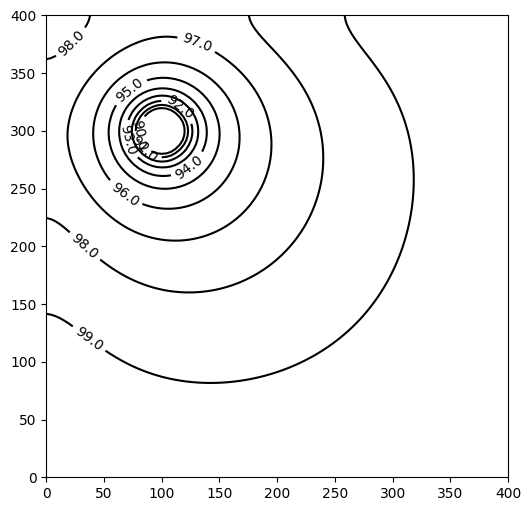

In [68]:
x = y = np.linspace(0, L, N)
y = y[::-1]
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(1, 1, 1, aspect="equal")
c = ax.contour(x, y, h[-1], contour_intervals, colors="black")
plt.clabel(c, fmt="%1.1f")

<a list of 15 text.Text objects>

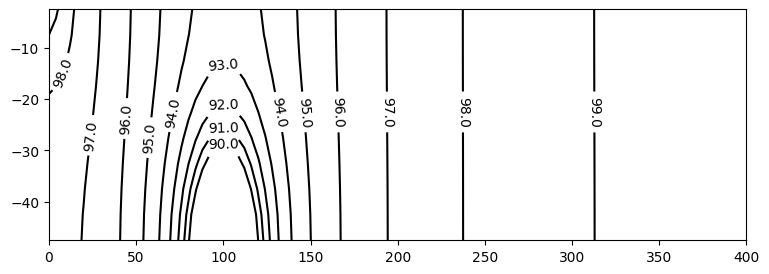

In [69]:
z = np.linspace(-H / Nlay / 2, -H + H / Nlay / 2, Nlay)
fig = plt.figure(figsize=(9, 3))
ax = fig.add_subplot(1, 1, 1, aspect="auto")
c = ax.contour(x, z, h[:, int(N / 4), :], contour_intervals, colors="black")
plt.clabel(c, fmt="%1.1f")

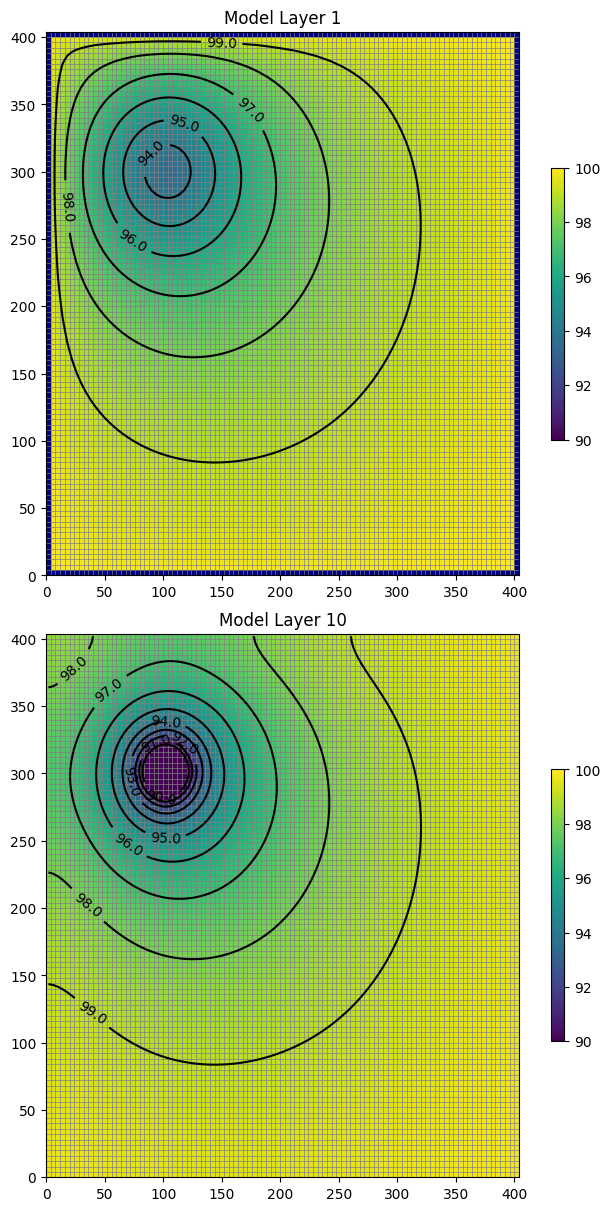

In [70]:
fig, axes = plt.subplots(2, 1, figsize=(6, 12), constrained_layout=True)
# first subplot
ax = axes[0]
ax.set_title("Model Layer 1")
modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax)
pa = modelmap.plot_array(h, vmin=vmin, vmax=vmax)
quadmesh = modelmap.plot_bc("CHD")
linecollection = modelmap.plot_grid(lw=0.5, color="0.5")
contours = modelmap.contour_array(h, levels=contour_intervals, colors="black")
ax.clabel(contours, fmt="%2.1f")
cb = plt.colorbar(pa, shrink=0.5, ax=ax)
# second subplot
ax = axes[1]
ax.set_title(f"Model Layer {Nlay}")
modelmap = flopy.plot.PlotMapView(model=gwf, ax=ax, layer=Nlay - 1)
linecollection = modelmap.plot_grid(lw=0.5, color="0.5")
pa = modelmap.plot_array(h, vmin=vmin, vmax=vmax)
quadmesh = modelmap.plot_bc("CHD")
contours = modelmap.contour_array(h, levels=contour_intervals, colors="black")
ax.clabel(contours, fmt="%2.1f")
cb = plt.colorbar(pa, shrink=0.5, ax=ax)